# Atividade RLS - Estimação Sequencial (Aeropêndulo)

Neste notebook, revisitamos o sistema do Aeropêndulo estimado anteriormente com Batch Least Squares (BLS), utilizando agora uma abordagem de estimação sequencial: **Recursive Least Squares (RLS)**.

O objetivo é observar a evolução dos parâmetros a cada passo de tempo e comparar se os valores convergem para os mesmos resultados obtidos pelo método Batch (BLS).

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 1. Carregamento dos Dados

Utilizaremos o mesmo dataset uniforme (degraus) usado no exercício anterior.

Dados de Treinamento: 6904 amostras


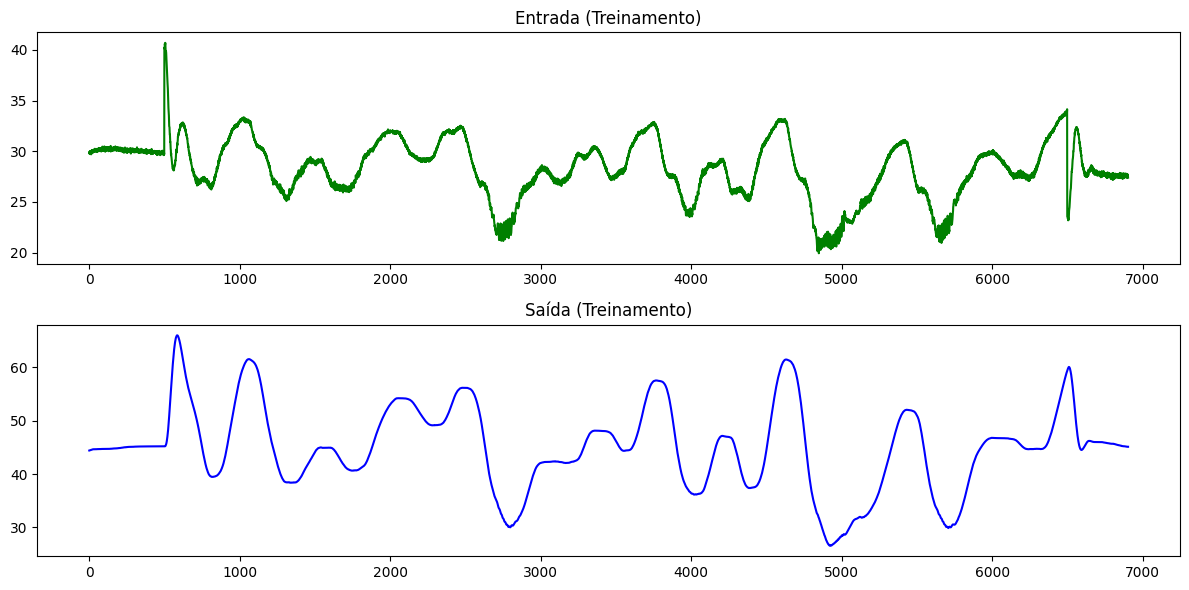

In [26]:
def carregar_experimento(url, decimacao=1, start_idx=0, end_idx=None):
    df = pd.read_csv(url)
    df_sub = df.iloc[::decimacao].copy().reset_index(drop=True)
    
    # Suporte para cabeçalhos antigos (motor_percent) e novos (u_pct)
    if 'u_pct' in df_sub.columns:
        u_raw = df_sub['u_pct'].values
    else:
        u_raw = df_sub['motor_percent'].values
        
    y_raw = df_sub['angulo_deg'].values
    
    if end_idx is None:
        end_idx = len(u_raw)
        
    u = u_raw[start_idx:end_idx]
    y = y_raw[start_idx:end_idx]
    return u, y
    
BASE = (
    "https://raw.githubusercontent.com/FelipeEduardoMarcondes/"
    "SYSTEM-IDENTIFICATION-AERO/main/PYTHON/dados/"
)


BASE2 = (
    "https://raw.githubusercontent.com/FelipeEduardoMarcondes/"
    "SYSTEM-IDENTIFICATION-AERO/main/experimentos/"
)



# Define limites de corte para remover ruído inicial e final
CUT_TRA_START = 1500
CUT_TRA_END = -1400

CUT_TEST_START = 1500
CUT_TEST_END = -1400

u_TRA,  y_TRA  = carregar_experimento(BASE2 + "RODADA-1/multi-sine-1_0731_17-34.csv", start_idx=CUT_TRA_START, end_idx=CUT_TRA_END) # Estimação
u_TEST, y_TEST = carregar_experimento(BASE2 + "RODADA-1/multi-sine-3_0731_17-45.csv", start_idx=CUT_TEST_START, end_idx=CUT_TEST_END) # Teste  # Teste 

print(f"Dados de Treinamento: {len(u_TRA)} amostras")

# Visualização rápida
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(u_TRA, color='green')
axes[0].set_title('Entrada (Treinamento)')
axes[1].plot(y_TRA, color='blue')
axes[1].set_title('Saída (Treinamento)')
plt.tight_layout()
plt.show()

## 2. Implementação do RLS (Recursive Least Squares) e BLS (Batch)

Vamos definir ordens simples ($na=2, nb=2$) para conseguirmos visualizar claramente a evolução dos 4 parâmetros no tempo.

In [27]:
na = 2
nb = 2
p = max(na, nb)
N = len(u_TRA)
num_params = na + nb

# ==========================================
# 2.1 BATCH LEAST SQUARES (BLS) - Referência
# ==========================================
Phi_bls = np.zeros((N - p, num_params))
y_target = y_TRA[p:]

for i in range(1, na + 1):
    Phi_bls[:, i - 1] = -y_TRA[p - i: N - i]
for i in range(1, nb + 1):
    Phi_bls[:, na + i - 1] = u_TRA[p - i: N - i]

theta_bls, _, _, _ = np.linalg.lstsq(Phi_bls, y_target, rcond=None)
print("Parâmetros BLS finais:", theta_bls)

# ==========================================
# 2.2 RECURSIVE LEAST SQUARES (RLS)
# ==========================================
theta_rls = np.zeros((num_params, 1))  # theta(0)
P = np.eye(num_params) * 1000.0        # P(0) - Alta incerteza inicial
lam = 1.0                              # Fator de esquecimento

# Histórico de parâmetros para plotagem
theta_history = np.zeros((N, num_params))
y_est_rls = np.zeros(N)

for k in range(p, N):
    # Constrói o regressor phi(k)
    phi_k = np.zeros((num_params, 1))
    for i in range(1, na + 1):
        phi_k[i - 1, 0] = -y_TRA[k - i]
    for i in range(1, nb + 1):
        phi_k[na + i - 1, 0] = u_TRA[k - i]
        
    # Calcula o ganho K(k)
    P_phi = P @ phi_k
    K = P_phi / (lam + phi_k.T @ P_phi)
    
    # Previsão um passo à frente (apriori)
    y_hat = (phi_k.T @ theta_rls).item()
    y_est_rls[k] = y_hat
    
    # Erro e atualização de parâmetros
    e = y_TRA[k] - y_hat
    theta_rls = theta_rls + K * e
    
    # Atualização da matriz de covariância
    P = (P - K @ phi_k.T @ P) / lam
    
    # Salva o estado atual do theta
    theta_history[k, :] = theta_rls.flatten()

print("Parâmetros RLS finais:", theta_rls.flatten())

Parâmetros BLS finais: [-1.98312822  0.98349087  0.00594046 -0.00535886]
Parâmetros RLS finais: [-1.98306311  0.98342608  0.00593968 -0.00535757]


## 3. Comparação de Parâmetros (Evolução RLS vs. Fixo BLS)

No gráfico abaixo verificamos se as mudanças de parâmetros estimados alinham com o que obtivemos no Batch Least Squares após todo o dataset.

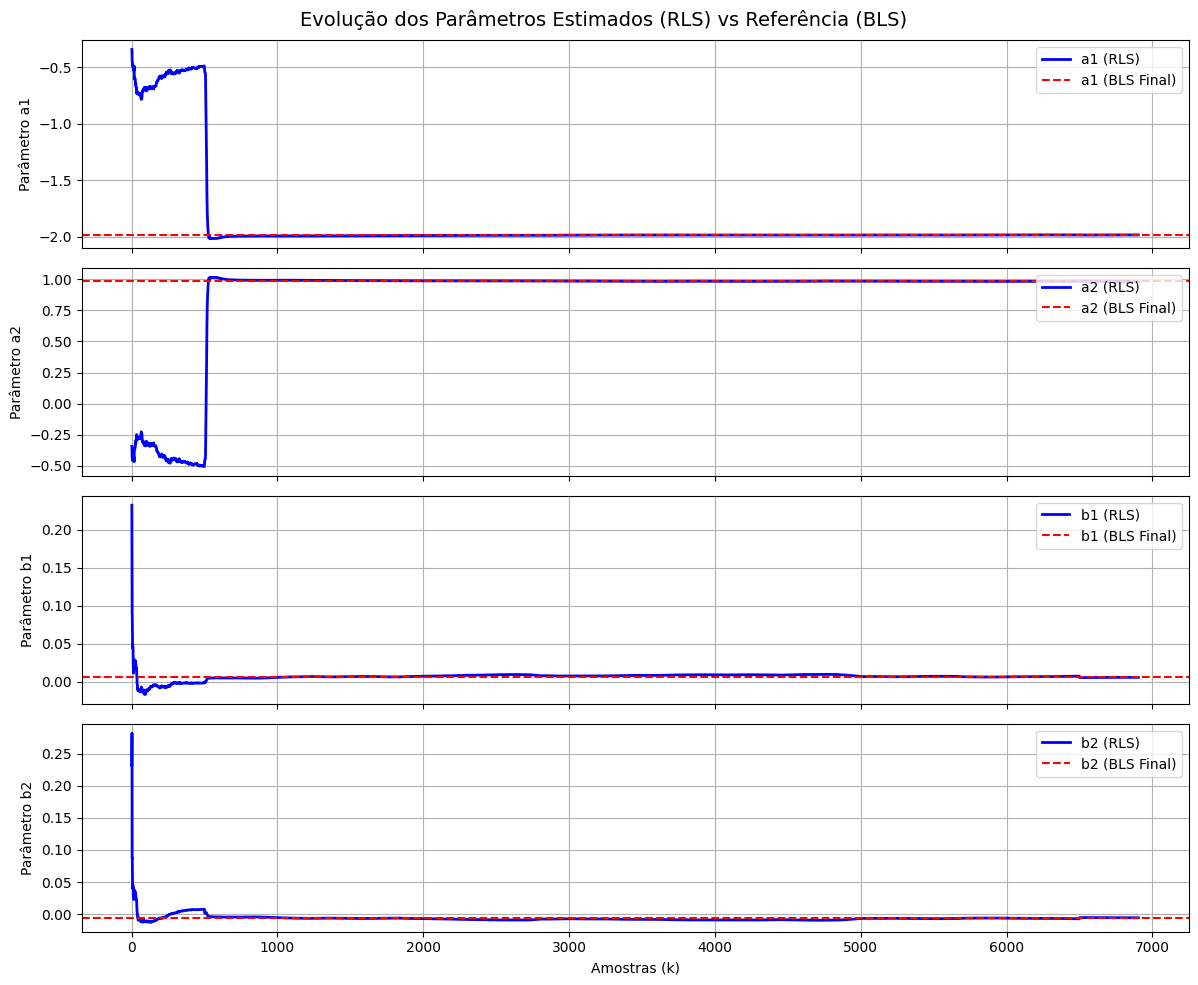

In [28]:
fig, axes = plt.subplots(num_params, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Evolução dos Parâmetros Estimados (RLS) vs Referência (BLS)', fontsize=14)

t = np.arange(p, N)
labels = [f'a{i}' for i in range(1, na+1)] + [f'b{i}' for i in range(1, nb+1)]

for i in range(num_params):
    # Plota a evolução do RLS
    axes[i].plot(t, theta_history[p:, i], label=f'{labels[i]} (RLS)', color='blue', lw=2)
    # Plota a linha reta correspondente ao valor obtido no BLS
    axes[i].axhline(theta_bls[i], color='red', linestyle='--', label=f'{labels[i]} (BLS Final)')
    
    axes[i].set_ylabel(f'Parâmetro {labels[i]}')
    axes[i].grid(True)
    axes[i].legend(loc='upper right')

axes[-1].set_xlabel('Amostras (k)')
plt.tight_layout()
plt.show()

## 4. Plot output: Real vs Estimated Parameters

Comparamos o sinal predito (One-Step Ahead) gerado pelo BLS e pelo RLS de forma simultânea contra os dados medidos.

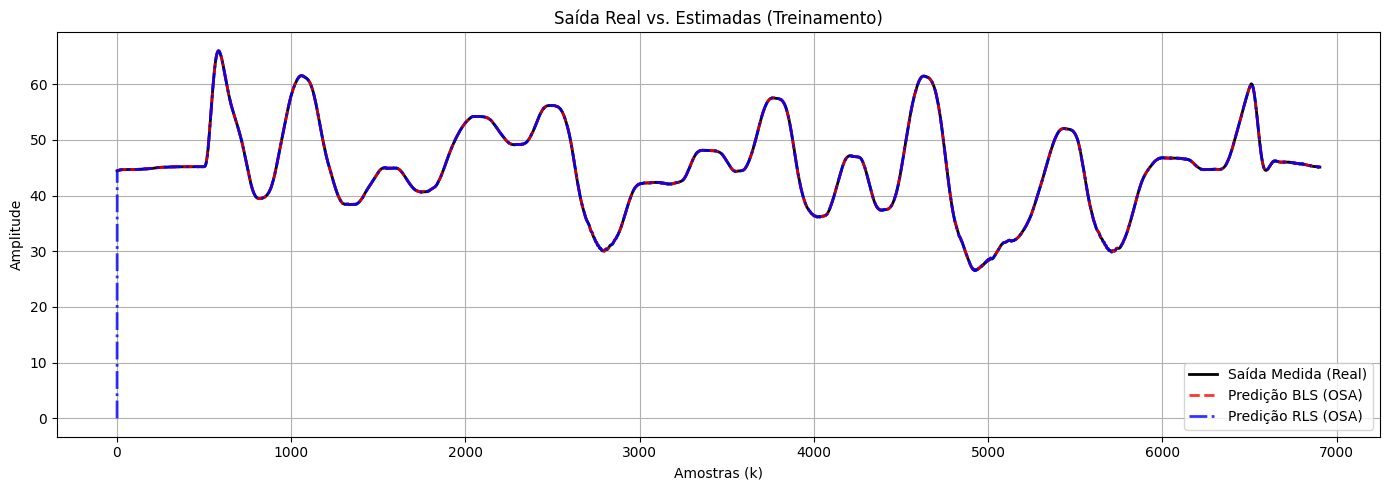

In [29]:
y_est_bls = np.zeros(N)
y_est_bls[:p] = y_TRA[:p]
y_est_bls[p:] = Phi_bls @ theta_bls

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(t, y_TRA[p:], color='black', lw=2, label='Saída Medida (Real)')
ax.plot(t, y_est_bls[p:], color='red', ls='--', lw=2, alpha=0.8, label='Predição BLS (OSA)')
ax.plot(t, y_est_rls[p:], color='blue', ls='-.', lw=2, alpha=0.8, label='Predição RLS (OSA)')

ax.set_title('Saída Real vs. Estimadas (Treinamento)')
ax.set_xlabel('Amostras (k)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

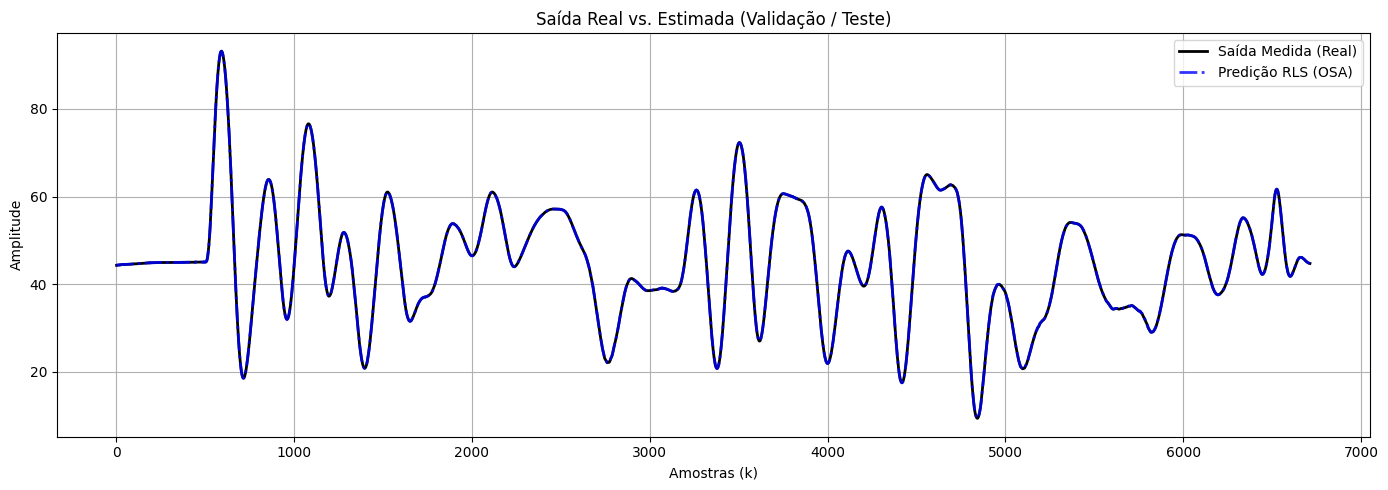

In [30]:
# ==========================================
# 3. VALIDAÇÃO NA BASE DE TESTE
# ==========================================

N_test = len(u_TEST)
y_est_rls_test = np.zeros(N_test)
y_est_rls_test[:p] = y_TEST[:p]

for k in range(p, N_test):
    phi_k = np.zeros((num_params, 1))
    for i in range(1, na + 1):
        phi_k[i - 1, 0] = -y_TEST[k - i]
    for i in range(1, nb + 1):
        phi_k[na + i - 1, 0] = u_TEST[k - i]
        
    y_hat = (phi_k.T @ theta_rls).item()
    y_est_rls_test[k] = y_hat

t_test = np.arange(p, N_test)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_test, y_TEST[p:], color='black', lw=2, label='Saída Medida (Real)')
ax.plot(t_test, y_est_rls_test[p:], color='blue', ls='-.', lw=2, alpha=0.8, label='Predição RLS (OSA)')

ax.set_title('Saída Real vs. Estimada (Validação / Teste)')
ax.set_xlabel('Amostras (k)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()
